In [1]:
%load_ext autoreload


In [2]:
%autoreload 2

In [3]:
# %% [markdown]
# # Exploratory Data Analysis — Give Me Some Credit (GMSC) Dataset
# 
# **Dataset:** Kaggle Give Me Some Credit (150,000 samples, 11 features)
# **Target:** `SeriousDlqin2yrs` (renamed to `Class`)

# %%


# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add scripts folder to path
sys.path.append(os.path.abspath("../scripts"))

# Import our custom EDA functions
from eda_functions import *

# Settings
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)


In [4]:

# %% [markdown]
# ## 1. Load Dataset

# %%
# Load the training data
df = load_data("../data/raw/GMSC-training.csv", clean_cols=True, drop_unnamed=True)


In [5]:

# Rename target column
df = df.rename(columns={'SeriousDlqin2yrs': 'Class'})




In [6]:

# Preview
print(f"Dataset Shape: {df.shape}")
df.head()


Dataset Shape: (150000, 11)


,Class,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [7]:

# %% [markdown]
# ## 2. Dataset Overview

# %%
overview(df)


===== DATASET OVERVIEW =====
Shape: 150000 rows, 11 columns

Data Types:
 Class                                     int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object 

Missing Values:
 Class                                       0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                    

In [8]:

# %% [markdown]
# ## 3. Feature Descriptions

# %%
column_descriptions = {
    'Class': 'Target: 1 = 90+ days past due or worse (default)',
    'RevolvingUtilizationOfUnsecuredLines': 'Total balance on credit cards / total credit limit',
    'age': 'Age of borrower (years)',
    'NumberOfTime30-59DaysPastDueNotWorse': 'Times 30-59 days past due (last 2 years)',
    'DebtRatio': 'Monthly debt payments / monthly gross income',
    'MonthlyIncome': 'Monthly income',
    'NumberOfOpenCreditLinesAndLoans': 'Number of open loans and credit lines',
    'NumberOfTimes90DaysLate': 'Times 90+ days past due (last 2 years)',
    'NumberRealEstateLoansOrLines': 'Number of mortgage and real estate loans',
    'NumberOfTime60-89DaysPastDueNotWorse': 'Times 60-89 days past due (last 2 years)',
    'NumberOfDependents': 'Number of dependents in family',
}

print("Feature descriptions:")
for col, desc in column_descriptions.items():
    if col in df.columns:
        print(f"  {col:45s}: {desc}")


Feature descriptions:
  Class                                        : Target: 1 = 90+ days past due or worse (default)
  RevolvingUtilizationOfUnsecuredLines         : Total balance on credit cards / total credit limit
  age                                          : Age of borrower (years)
  NumberOfTime30-59DaysPastDueNotWorse         : Times 30-59 days past due (last 2 years)
  DebtRatio                                    : Monthly debt payments / monthly gross income
  MonthlyIncome                                : Monthly income
  NumberOfOpenCreditLinesAndLoans              : Number of open loans and credit lines
  NumberOfTimes90DaysLate                      : Times 90+ days past due (last 2 years)
  NumberRealEstateLoansOrLines                 : Number of mortgage and real estate loans
  NumberOfTime60-89DaysPastDueNotWorse         : Times 60-89 days past due (last 2 years)
  NumberOfDependents                           : Number of dependents in family


===== TARGET DISTRIBUTION =====
Class
0    139974
1     10026
Name: count, dtype: int64

Imbalance Ratio: 13.96:1
Default Rate: 6.68%


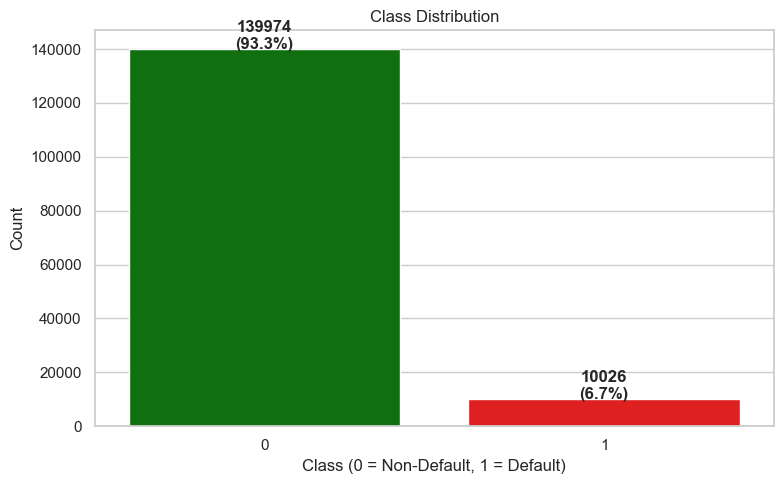

In [9]:

# %% [markdown]
# ## 4. Target Variable Distribution

# %%
plot_target_distribution(
    df, 
    target_col='Class',
    save_path='../../figures/gmsc_class_distribution.png'
)


In [10]:

# %% [markdown]
# ## 5. Feature Types

# %%
num_cols, cat_cols = get_feature_types(df, target='Class')
print("Numerical features:", num_cols)
print("Categorical features:", cat_cols if cat_cols else "None")


Numerical features: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
Categorical features: None


In [11]:

# %% [markdown]
# ## 6. Numerical Feature Analysis

# %% [markdown]
# ### 6.1 Descriptive Statistics

# %%
range_df = df[num_cols].agg(['min', 'max']).T
range_df.columns = ['Min', 'Max']
range_df['Range'] = range_df['Max'] - range_df['Min']
display(range_df)

# Display detailed statistics
df[num_cols].describe()


,Min,Max,Range
RevolvingUtilizationOfUnsecuredLines,0.0,50708.0,50708.0
age,0.0,109.0,109.0
NumberOfTime30-59DaysPastDueNotWorse,0.0,98.0,98.0
DebtRatio,0.0,329664.0,329664.0
MonthlyIncome,0.0,3008750.0,3008750.0
NumberOfOpenCreditLinesAndLoans,0.0,58.0,58.0
NumberOfTimes90DaysLate,0.0,98.0,98.0
NumberRealEstateLoansOrLines,0.0,54.0,54.0
NumberOfTime60-89DaysPastDueNotWorse,0.0,98.0,98.0
NumberOfDependents,0.0,20.0,20.0


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


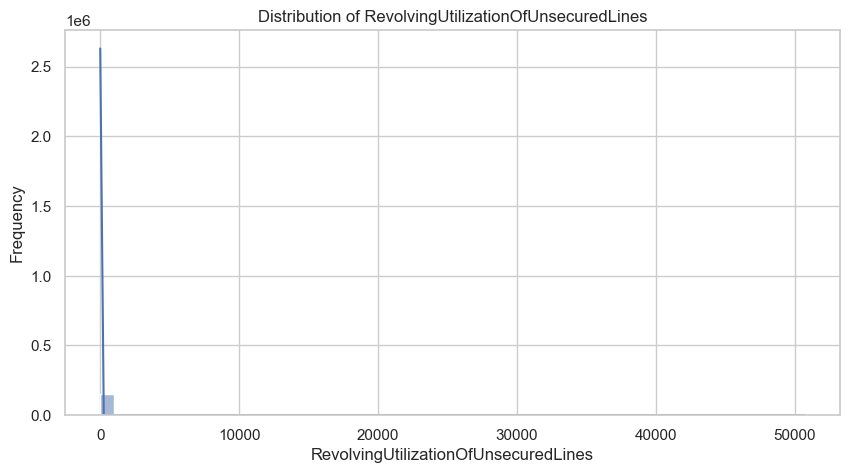

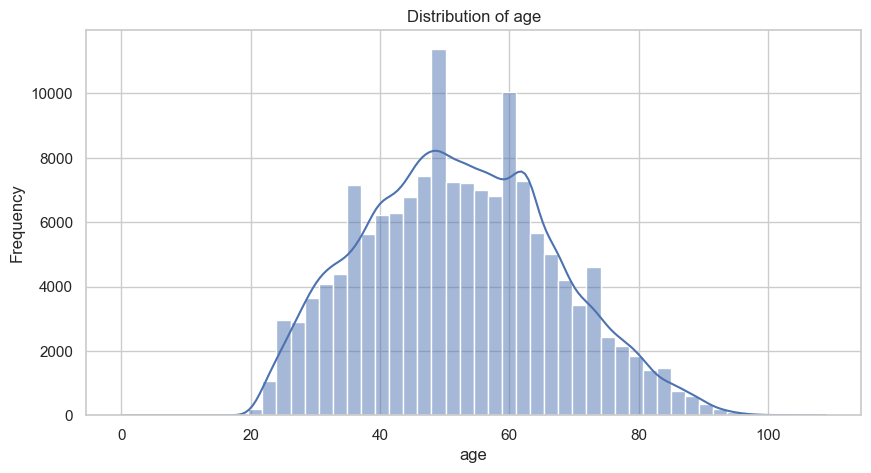

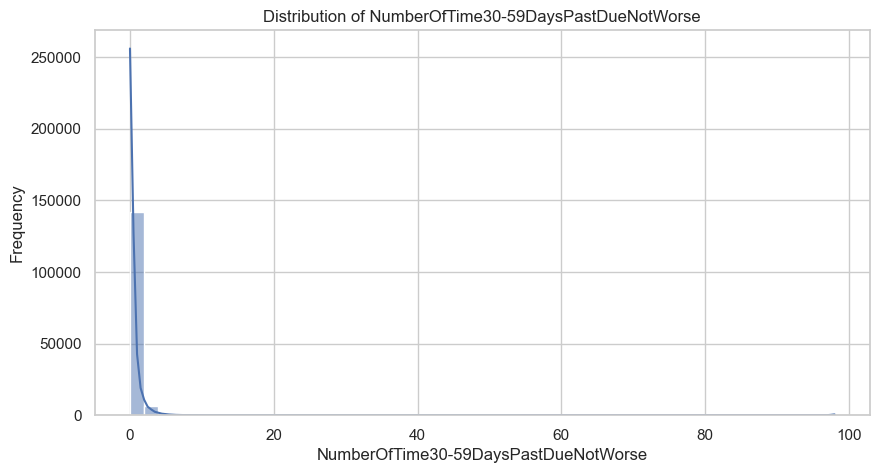

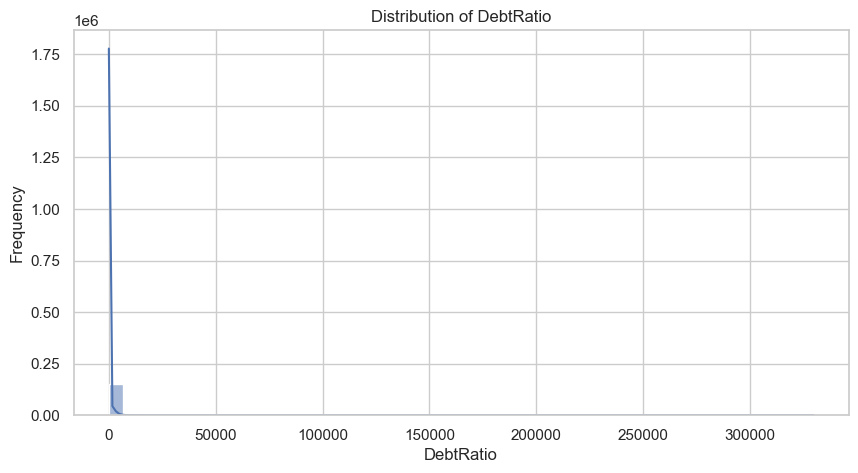

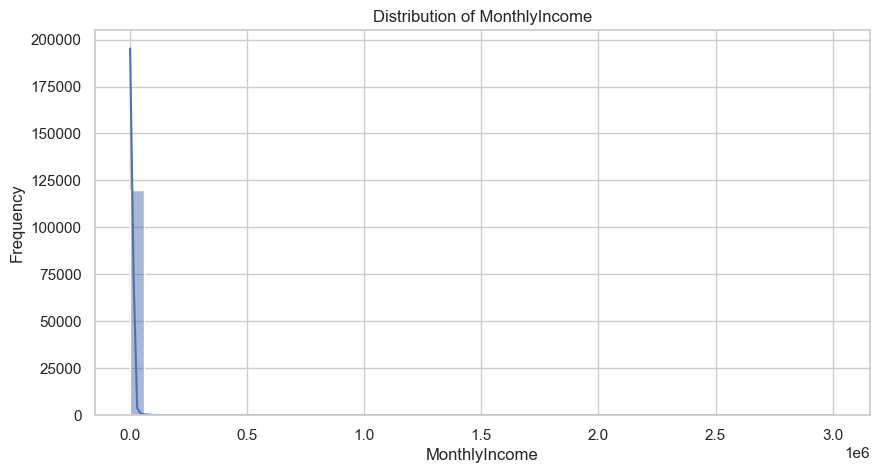

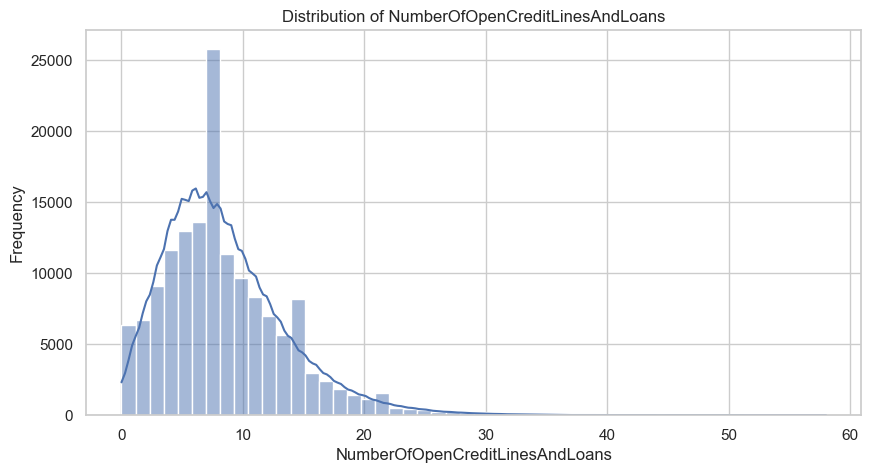

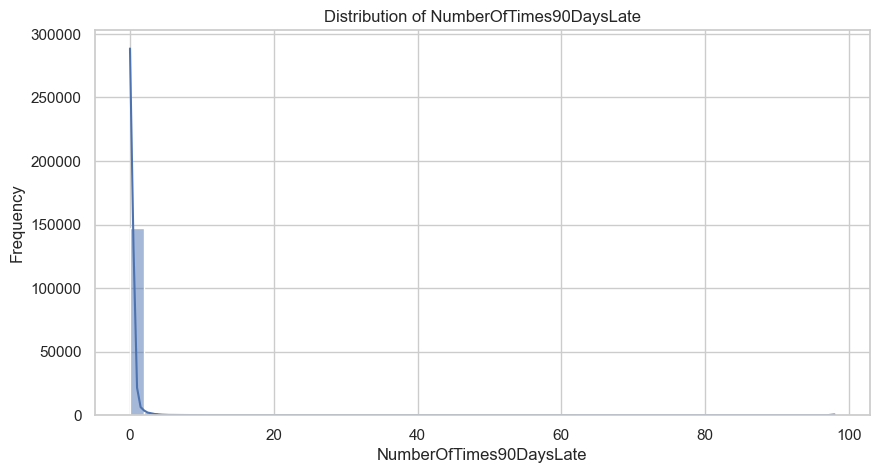

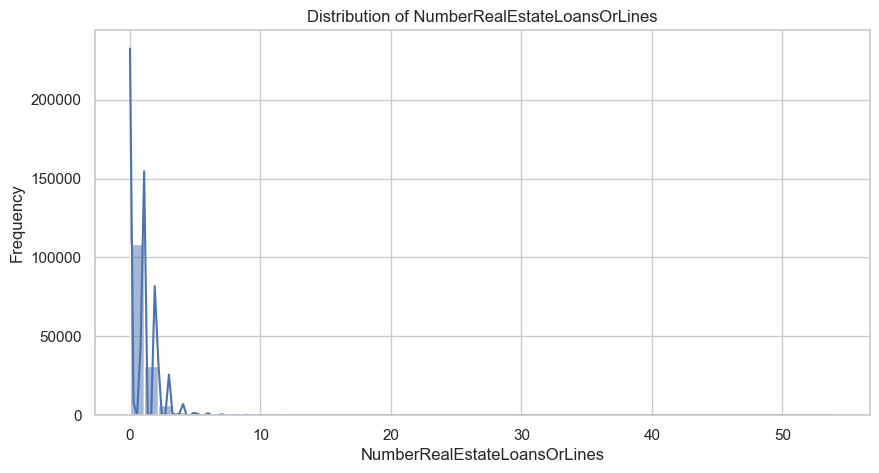

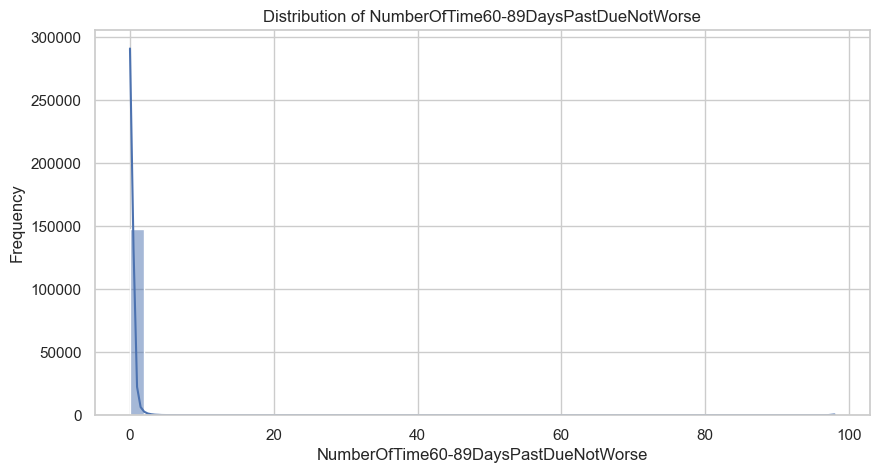

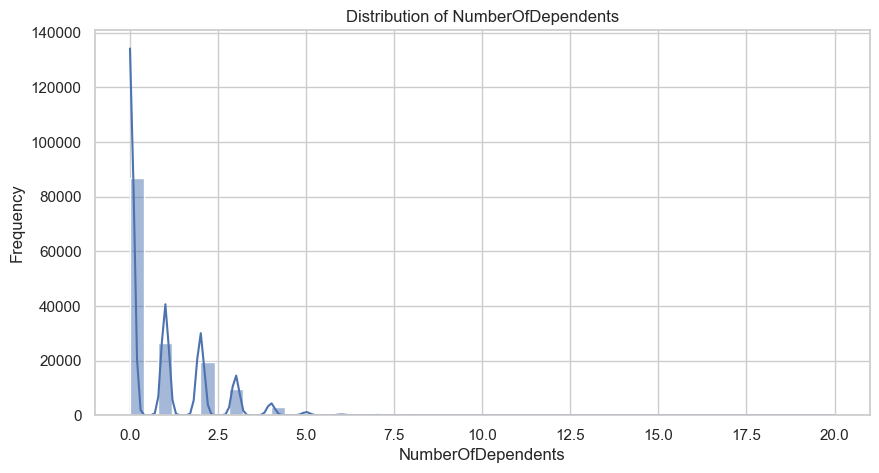

In [12]:

# %% [markdown]
# ### 6.2 Histograms with KDE

# %%
# Select key features for cleaner visualization
key_features = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans'
]
plot_numerical(df, cols=num_cols, kde=True, bins=50)


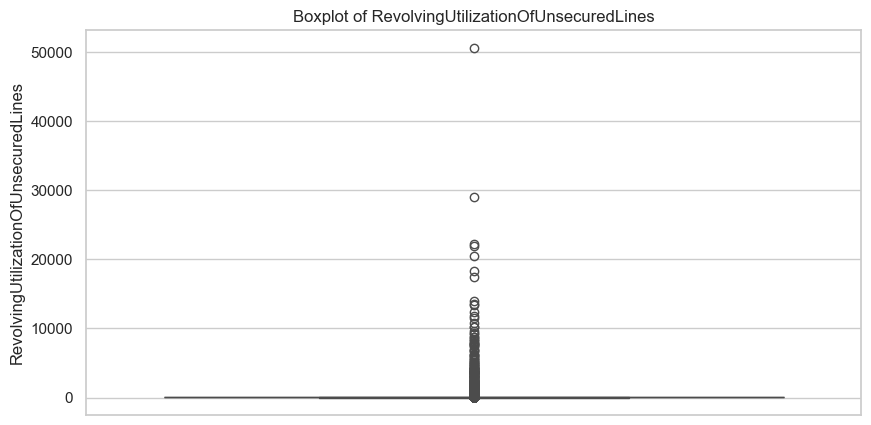

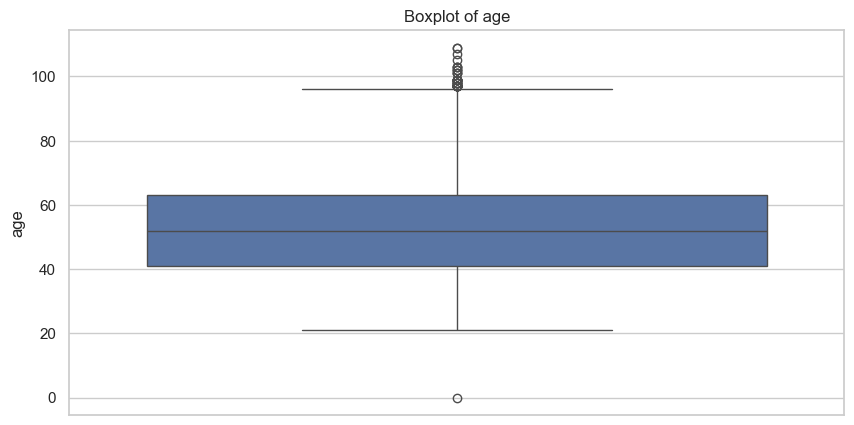

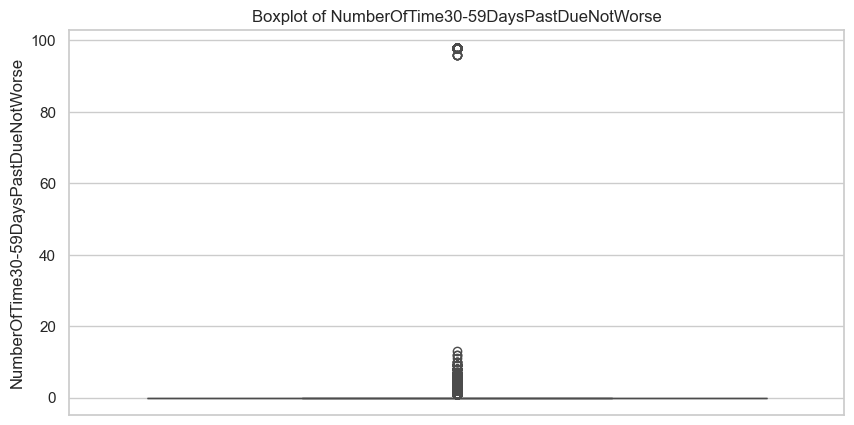

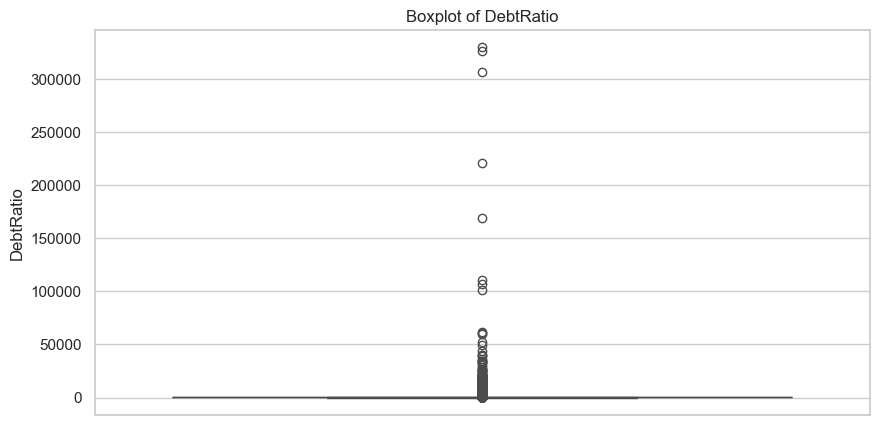

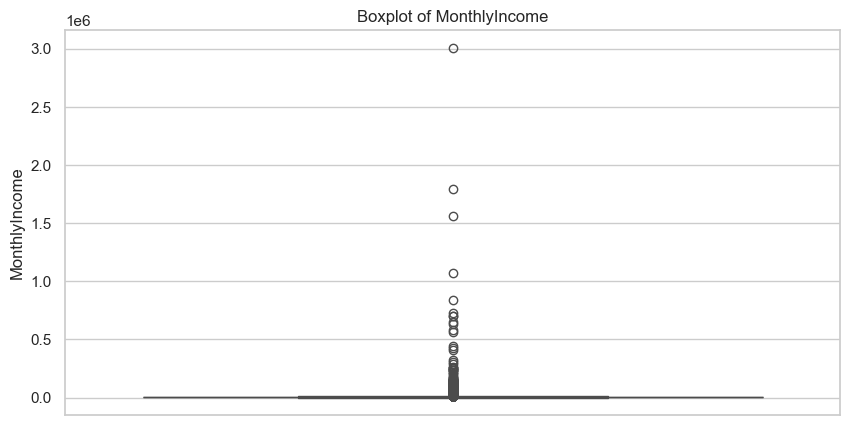

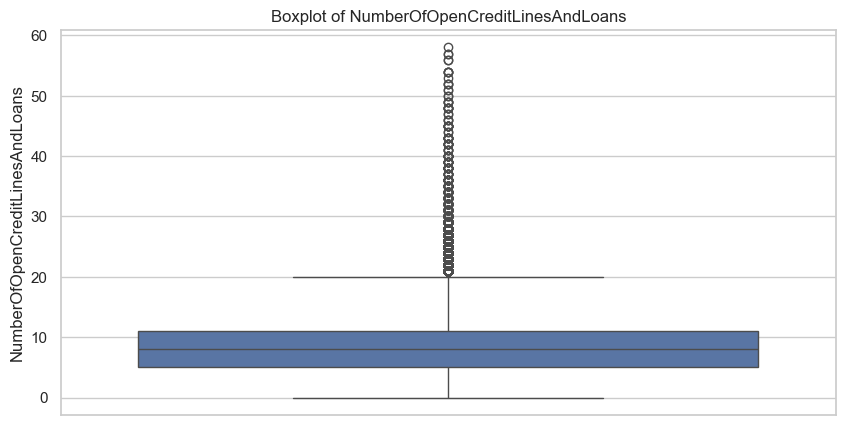

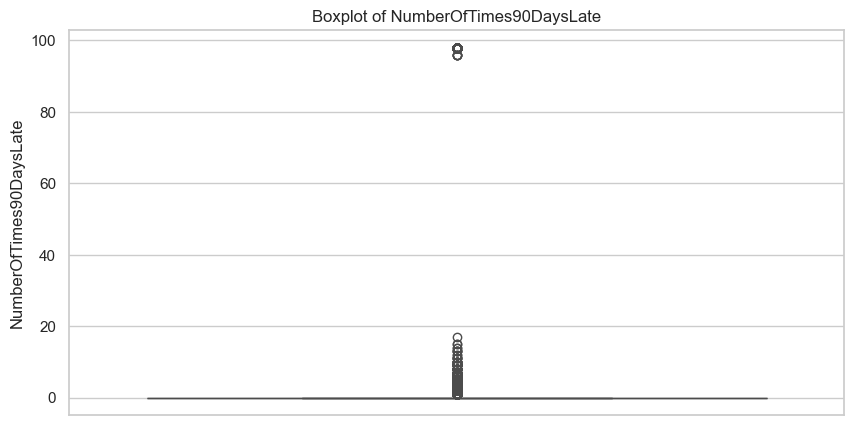

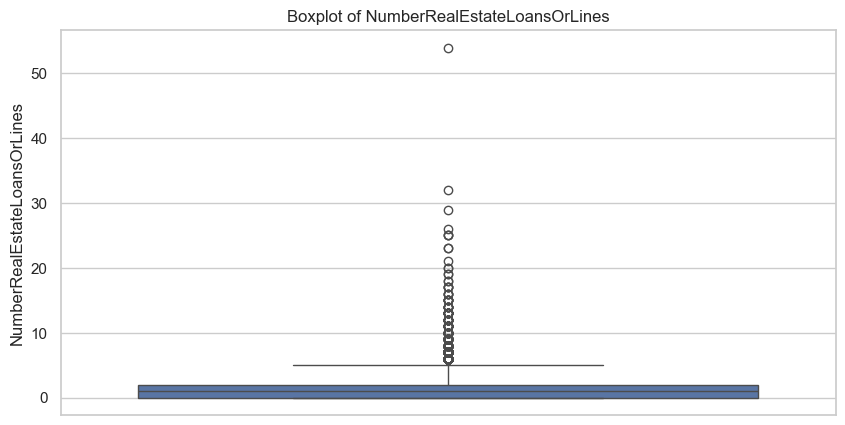

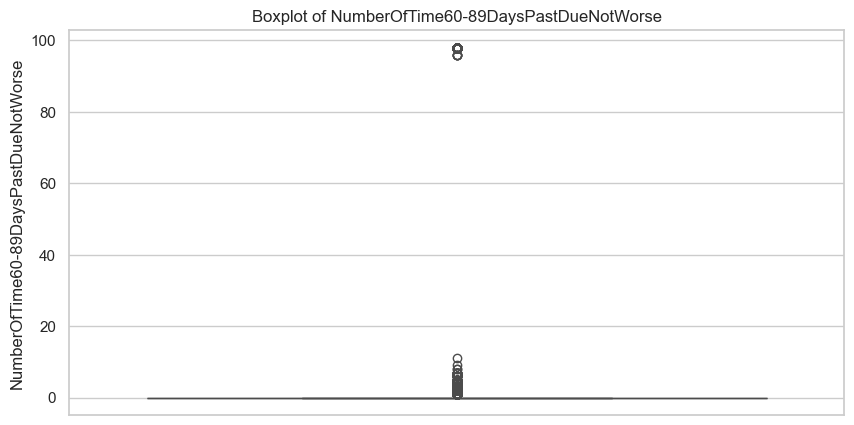

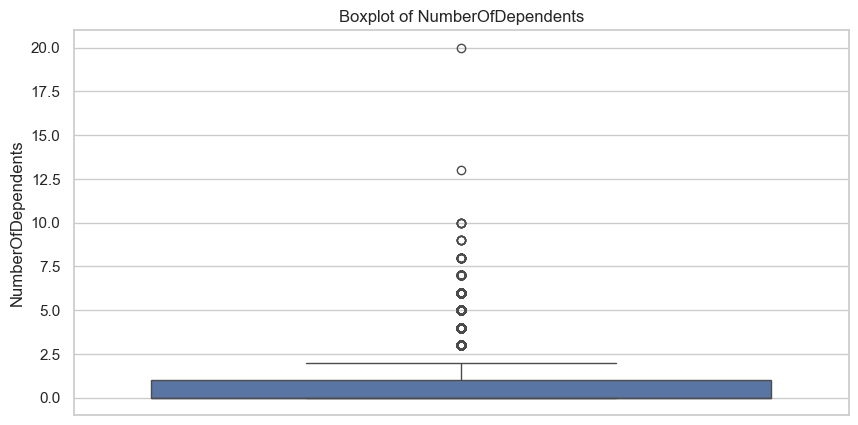

In [13]:

# %% [markdown]
# ### 6.3 Boxplots (Outlier Detection)

# %%
# Boxplots for selected features
plot_outliers_boxplot(df, cols=num_cols)


In [25]:

# %% [markdown]
# ## 7. Categorical Feature Analysis

# %%
# Value counts for each categorical feature
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


In [24]:
print(df["age"].value_counts())

age
49     3837
48     3806
50     3753
47     3719
63     3719
       ... 
102       3
109       2
107       1
105       1
0         1
Name: count, Length: 86, dtype: int64


In [15]:
for col in num_cols:
    print(f"\n{col}")
    print(df[col].value_counts())



RevolvingUtilizationOfUnsecuredLines
RevolvingUtilizationOfUnsecuredLines
0.000000    10878
1.000000    10256
1.000000       17
0.950100        8
0.007984        6
            ...  
0.954162        1
0.820080        1
0.176771        1
0.084661        1
0.850283        1
Name: count, Length: 125728, dtype: int64

age
age
49     3837
48     3806
50     3753
47     3719
63     3719
       ... 
102       3
109       2
107       1
105       1
0         1
Name: count, Length: 86, dtype: int64

NumberOfTime30-59DaysPastDueNotWorse
NumberOfTime30-59DaysPastDueNotWorse
0     126018
1      16033
2       4598
3       1754
4        747
5        342
98       264
6        140
7         54
8         25
9         12
96         5
10         4
12         2
13         1
11         1
Name: count, dtype: int64

DebtRatio
DebtRatio
0.000000    4113
1.000000     229
4.000000     174
2.000000     170
3.000000     162
            ... 
0.368763       1
0.108009       1
0.441337       1
1.006015       1
0.2499

In [16]:

# %% [markdown]
# ## 8. Bivariate Analysis (Feature vs Target)

# %% [markdown]
# ### 8.1 Categorical vs Target

# %%
if cat_cols:
    plot_cat_vs_target(df, cat_cols, target='Class')
else:
    print("No categorical features found.")


No categorical features found.


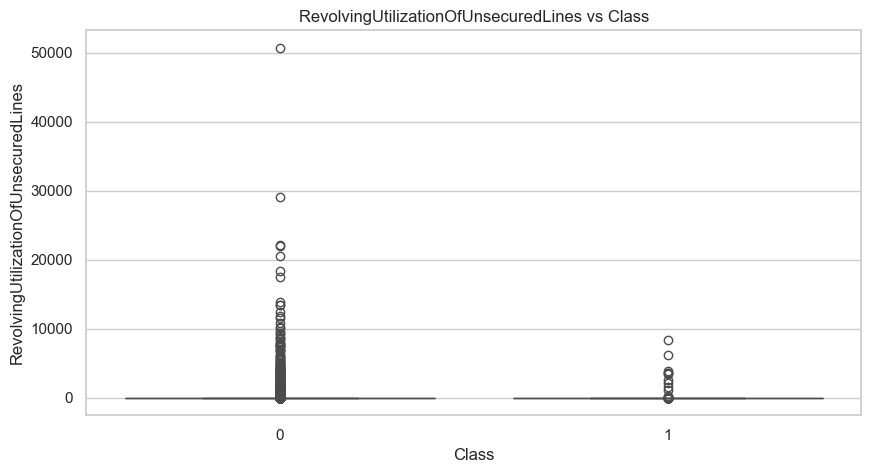

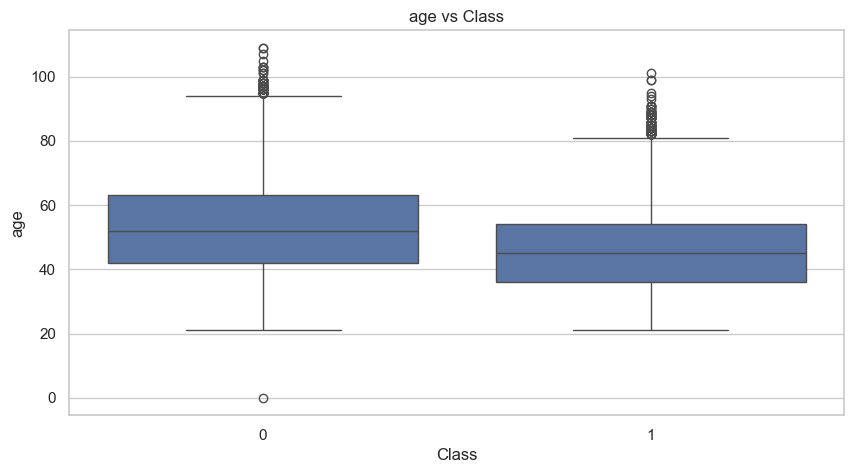

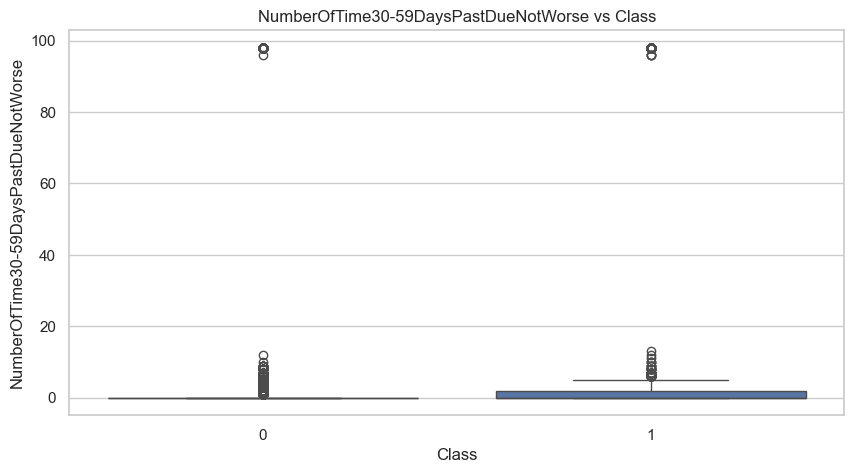

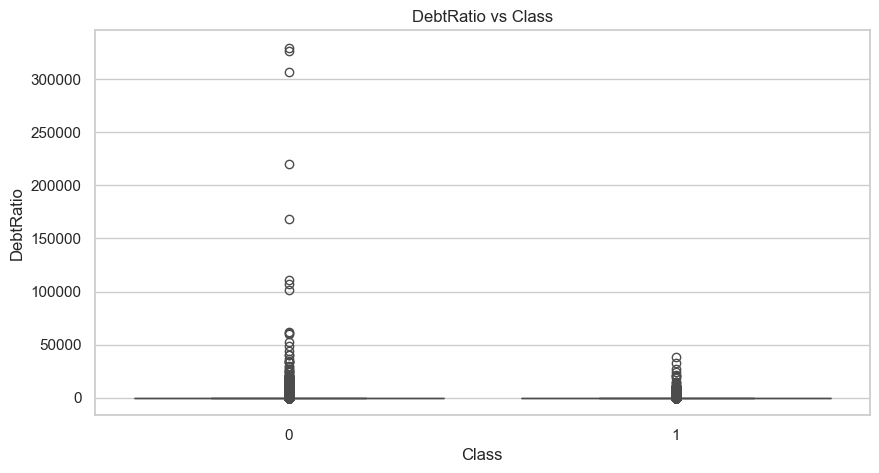

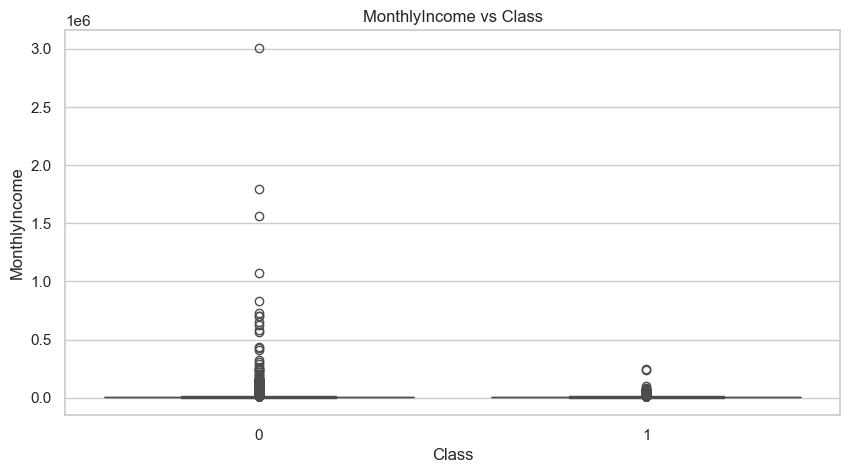

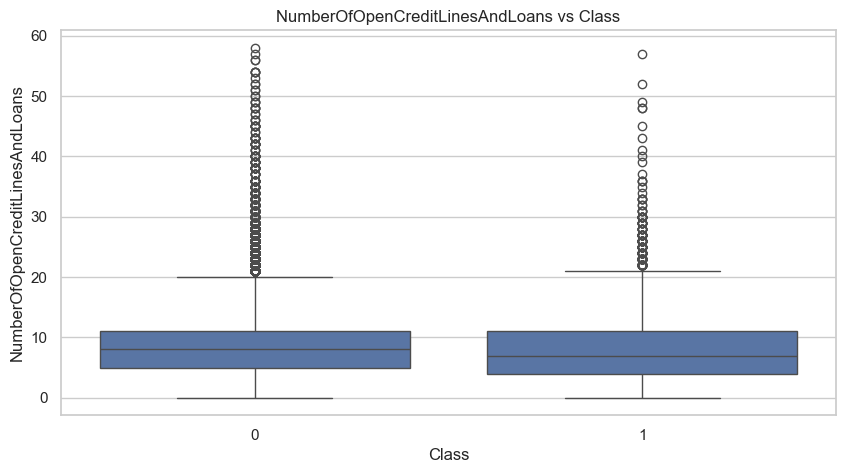

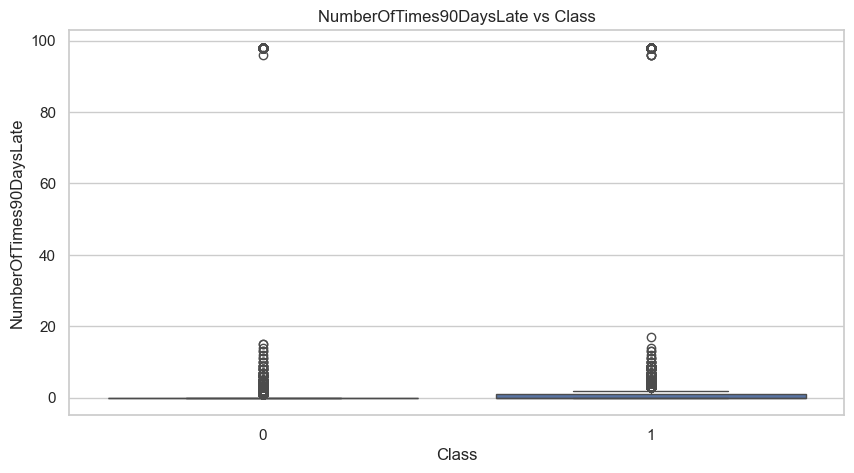

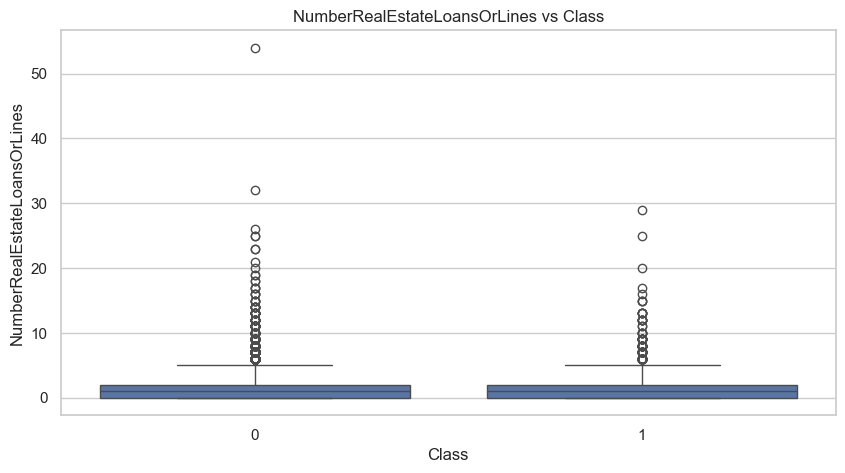

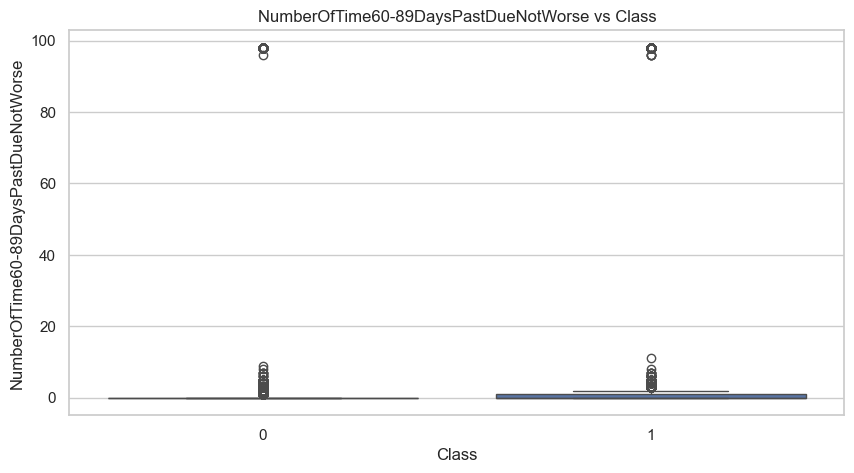

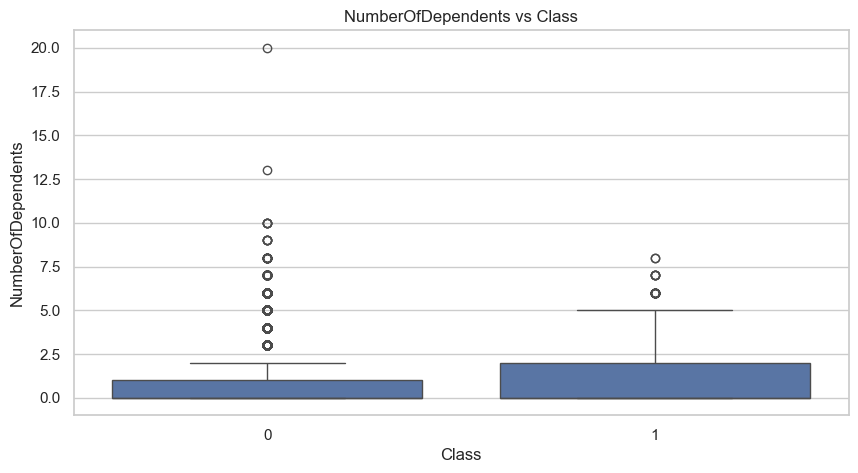

In [17]:

# %% [markdown]
# ### 8.2 Numerical vs Target (Boxplots)

# %%
plot_num_vs_target(df, num_cols=num_cols, target='Class')


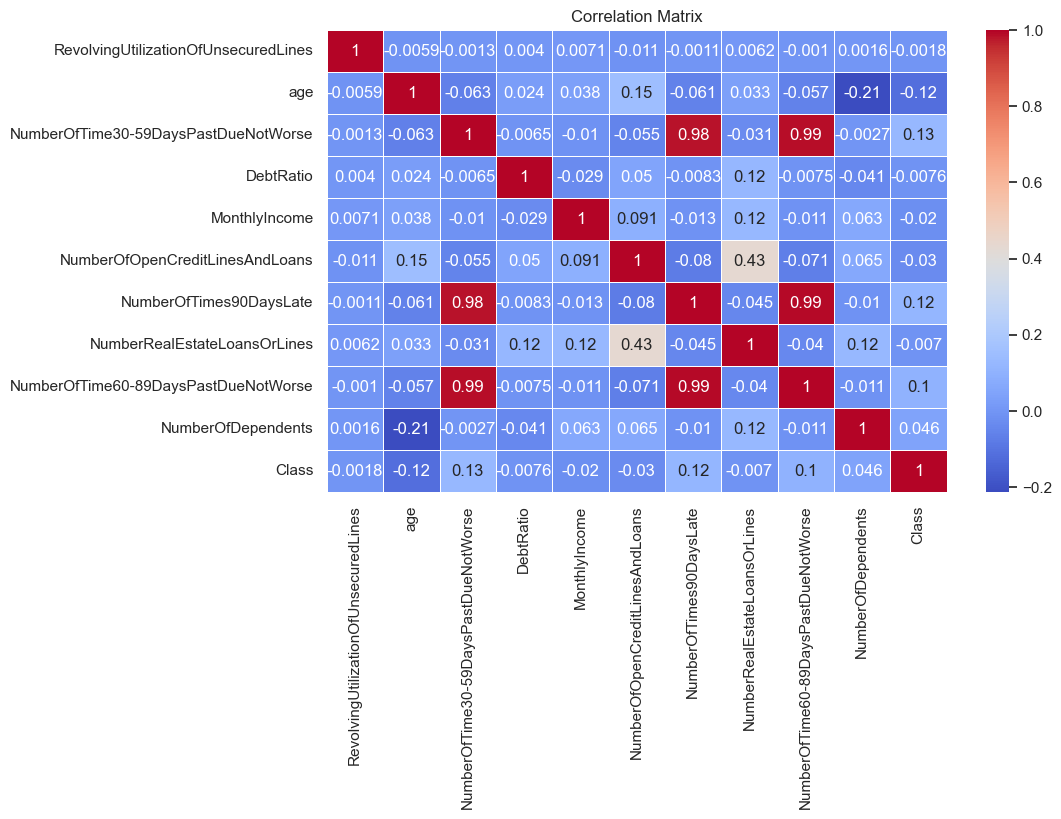

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,Class
RevolvingUtilizationOfUnsecuredLines,1.000000,-0.005898,-0.001314,0.003961,0.007124,-0.011281,-0.001061,0.006235,-0.001048,0.001557,-0.001802
age,-0.005898,1.000000,-0.062995,0.024188,0.037717,0.147705,-0.061005,0.033150,-0.057159,-0.213303,-0.115386
NumberOfTime30-59DaysPastDueNotWorse,-0.001314,-0.062995,1.000000,-0.006542,-0.010217,-0.055312,0.983603,-0.030565,0.987005,-0.002680,0.125587
DebtRatio,0.003961,0.024188,-0.006542,1.000000,-0.028712,0.049565,-0.008320,0.120046,-0.007533,-0.040673,-0.007602
MonthlyIncome,0.007124,0.037717,-0.010217,-0.028712,1.000000,0.091455,-0.012743,0.124959,-0.011116,0.062647,-0.019746
NumberOfOpenCreditLinesAndLoans,-0.011281,0.147705,-0.055312,0.049565,0.091455,1.000000,-0.079984,0.433959,-0.071077,0.065322,-0.029669
NumberOfTimes90DaysLate,-0.001061,-0.061005,0.983603,-0.008320,-0.012743,-0.079984,1.000000,-0.045205,0.992796,-0.010176,0.117175
NumberRealEstateLoansOrLines,0.006235,0.033150,-0.030565,0.120046,0.124959,0.433959,-0.045205,1.000000,-0.039722,0.124684,-0.007038
NumberOfTime60-89DaysPastDueNotWorse,-0.001048,-0.057159,0.987005,-0.007533,-0.011116,-0.071077,0.992796,-0.039722,1.000000,-0.010922,0.102261
NumberOfDependents,0.001557,-0.213303,-0.002680,-0.040673,0.062647,0.065322,-0.010176,0.124684,-0.010922,1.000000,0.046048


In [18]:

# %% [markdown]
# ## 9. Correlation Analysis

# %%
# Correlation heatmap including target
all_num = num_cols + ['Class']
correlation_heatmap(df, cols=all_num, annot=True, cmap='coolwarm')


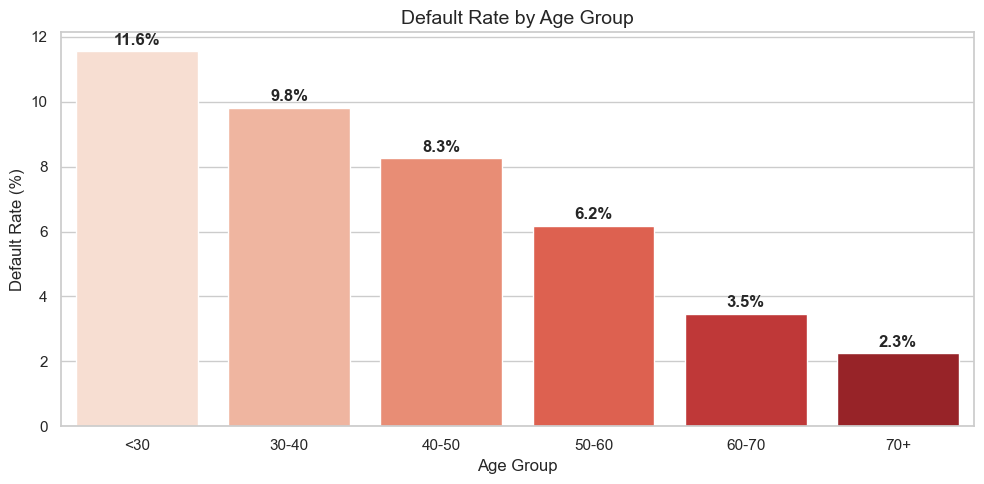


===== DEFAULT RATE BY NUMBER OF DEPENDENTS =====
  Dependents=  0: Default Rate= 5.86%  (n=86,902)
  Dependents=  1: Default Rate= 7.35%  (n=26,316)
  Dependents=  2: Default Rate= 8.11%  (n=19,522)
  Dependents=  3: Default Rate= 8.83%  (n=9,483)
  Dependents=  4: Default Rate=10.38%  (n=2,862)
  Dependents=  5: Default Rate= 9.12%  (n=746)
  Dependents=  6: Default Rate=15.19%  (n=158)
  Dependents=  7: Default Rate= 9.80%  (n=51)
  Dependents=  8: Default Rate= 8.33%  (n=24)
  Dependents=  9: Default Rate= 0.00%  (n=5)
  Dependents= 10: Default Rate= 0.00%  (n=5)
  Dependents= 13: Default Rate= 0.00%  (n=1)
  Dependents= 20: Default Rate= 0.00%  (n=1)


In [19]:

# %% [markdown]
# ## 10. Default Rate Analysis

# %%
# Default rate by age groups
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 40, 50, 60, 70, 120],
                         labels=['<30', '30-40', '40-50', '50-60', '60-70', '70+'])
default_by_age = df.groupby('age_group', observed=False)['Class'].mean() * 100

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=default_by_age.index, y=default_by_age.values, hue=default_by_age.index,
                 palette='Reds', legend=False)
ax.set_title('Default Rate by Age Group', fontsize=14)
ax.set_ylabel('Default Rate (%)')
ax.set_xlabel('Age Group')
for i, v in enumerate(default_by_age.values):
    ax.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../../figures/gmsc_default_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

# Default rate by number of dependents
default_by_dep = df.groupby('NumberOfDependents')['Class'].mean() * 100
dep_counts = df.groupby('NumberOfDependents').size()

print("\n===== DEFAULT RATE BY NUMBER OF DEPENDENTS =====")
for dep in sorted(default_by_dep.index):
    print(f"  Dependents={dep:3.0f}: Default Rate={default_by_dep[dep]:5.2f}%  (n={dep_counts[dep]:,})")

# Drop the temporary age_group column
df = df.drop('age_group', axis=1)


Missing values per column:
 MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64


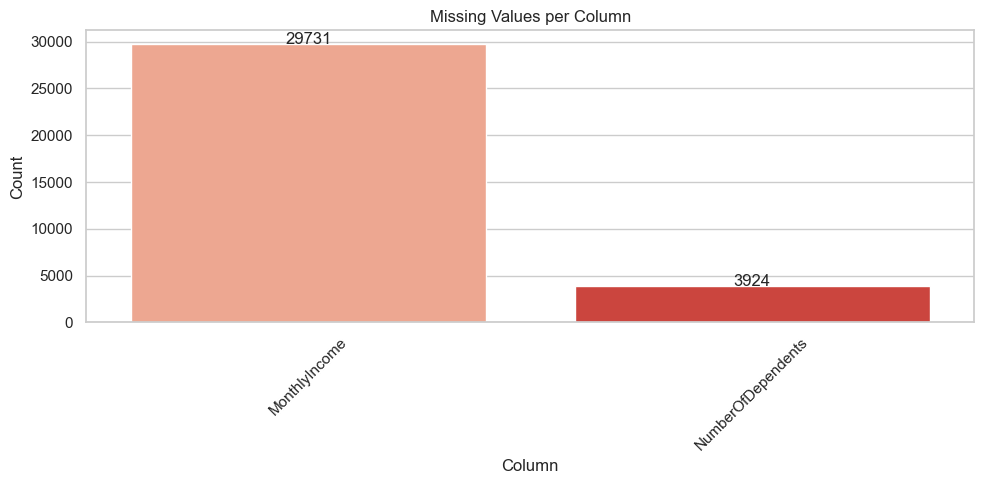

In [20]:

# %% [markdown]
# ## 11. Missing Values Analysis

# %%
missing = missing_values_report(df)

# Visualize missing values
if not missing.empty:
    plt.figure(figsize=(10, 5))
    missing_sorted = missing.sort_values(ascending=False)
    ax = sns.barplot(x=missing_sorted.index, y=missing_sorted.values, hue=missing_sorted.index,
                     palette='Reds', legend=False)
    ax.set_title('Missing Values per Column')
    ax.set_ylabel('Count')
    ax.set_xlabel('Column')
    plt.xticks(rotation=45)
    for i, v in enumerate(missing_sorted.values):
        ax.text(i, v + 10, str(v), ha='center')
    plt.tight_layout()
    plt.savefig('../../figures/gmsc_missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()


In [21]:

# %% [markdown]
# ## 12. Outlier Detection (IQR Method)

# %%
print("===== OUTLIER SUMMARY (IQR) =====")
outlier_summary(df, cols=num_cols)


===== OUTLIER SUMMARY (IQR) =====
RevolvingUtilizationOfUnsecuredLines: 763 outliers
age: 46 outliers
NumberOfTime30-59DaysPastDueNotWorse: 23982 outliers
DebtRatio: 31311 outliers
MonthlyIncome: 4879 outliers
NumberOfOpenCreditLinesAndLoans: 3980 outliers
NumberOfTimes90DaysLate: 8338 outliers
NumberRealEstateLoansOrLines: 793 outliers
NumberOfTime60-89DaysPastDueNotWorse: 7604 outliers
NumberOfDependents: 13336 outliers


In [22]:

# %% [markdown]
# ## 13. Key Insights

# %%
class_counts = df['Class'].value_counts()

print("===== KEY INSIGHTS =====")
print(f"1. Dataset size: {len(df):,} samples with {df.shape[1]} features")
print(f"2. Default rate: {df['Class'].mean()*100:.2f}%")
print(f"3. Imbalance ratio: {class_counts[0]/class_counts[1]:.2f}:1")
print(f"4. Severe class imbalance — only {class_counts[1]:,} defaulters")
print(f"5. Features with missing values: {missing.index.tolist() if not missing.empty else 'None'}")
print(f"6. MonthlyIncome and NumberOfDependents have significant missing data")
print(f"7. All features are numerical (no categorical columns)")
print(f"8. RevolvingUtilizationOfUnsecuredLines and DebtRatio are highly right‑skewed")
print(f"9. NumberOfTimes90DaysLate is strongly correlated with default")
print(f"10. Age shows moderate correlation with default risk")

print("\n✅ EDA Complete.")


===== KEY INSIGHTS =====
1. Dataset size: 150,000 samples with 11 features
2. Default rate: 6.68%
3. Imbalance ratio: 13.96:1
4. Severe class imbalance — only 10,026 defaulters
5. Features with missing values: ['MonthlyIncome', 'NumberOfDependents']
6. MonthlyIncome and NumberOfDependents have significant missing data
7. All features are numerical (no categorical columns)
8. RevolvingUtilizationOfUnsecuredLines and DebtRatio are highly right‑skewed
9. NumberOfTimes90DaysLate is strongly correlated with default
10. Age shows moderate correlation with default risk

✅ EDA Complete.


In [23]:

# %% [markdown]
# ## 14. Save EDA Cleaned Dataset

# %%
# Save the cleaned dataset (before scaling/imputation)
os.makedirs('../data/processed', exist_ok=True)
df.to_csv("../data/processed/gmsc_EDA_cleaned.csv", index=False)

print(f"✅ Cleaned dataset saved to ../data/processed/gmsc_EDA_cleaned.csv")
print(f"   Shape: {df.shape}")
print(f"   Class distribution:\n{df['Class'].value_counts()}")
print(f"   Columns with missing values:")
for col in df.columns:
    if df[col].isnull().sum() > 0:
        print(f"     {col}: {df[col].isnull().sum():,} missing ({df[col].isnull().mean()*100:.1f}%)")

✅ Cleaned dataset saved to ../data/processed/gmsc_EDA_cleaned.csv
   Shape: (150000, 11)
   Class distribution:
Class
0    139974
1     10026
Name: count, dtype: int64
   Columns with missing values:
     MonthlyIncome: 29,731 missing (19.8%)
     NumberOfDependents: 3,924 missing (2.6%)
